## Using EGO model for budgeted multi-target allocation optimization

This code extends the functionality of the `ego_2targets.py` script to handle scenarios with more than two targets while adhering to specified budget constraints. The implementation leverages the Efficient Global Optimization (EGO) framework to optimize resource allocation across multiple targets.

In [1]:
# Calling necessary libraries
import numpy as np
import matplotlib.pyplot as plt

from smt.applications import EGO
from smt.design_space import DesignSpace, FloatVariable
from smt.applications.mixed_integer import MixedIntegerContext
from smt.surrogate_models import KRG, MixIntKernelType

from utils import attacker_lingo_model, prob_success

In [2]:
# Parameters

n_targets = 5
alpha, beta, A = 1, 1, 0.1
T_BUDGET = 5 # Attacker's investment (Million USD)
G_BUDGET = 30 # Defender's Investment (Million USD)

# Infrastructure valuations for n targets
B = np.array([50, 20, 35, 45, 30]) # Attacker's valuations 
D = np.array([50, 150, 100, 80, 120]) # Defender's valuations

In [3]:
# Function to minimize

def def_loss_function(x):
    """Input target 1 allocation x, get defender losses (y)"""
    y = np.array([])
    for alloc1 in x:
        def_allocation = np.array(alloc1)
        att_allocation = attacker_lingo_model(
                n_targets=n_targets,
                alpha=alpha,
                beta=beta,
                A=A,
                t_budget=T_BUDGET,
                B_list=B,
                G_list=def_allocation
            )
        # Loss (y)
        loss = np.dot(D, [prob_success(Ti=Ti,Gi=Gi, alpha=alpha, beta=beta, Ai=A) for Ti,Gi in zip(att_allocation,def_allocation)])
        y = np.append(y, loss)
    return y.reshape((-1,1))

In [4]:
# Constrained EGO
from scipy.optimize import minimize

class EGOWithBudget(EGO):
    """
    Extended EGO class with budget constraint support.
    Adds a constraint sum(x) <= budget to the optimization problem.
    """
    
    def _initialize(self):
        super()._initialize()
        self.options.declare(
            "budget", 
            None, 
            types=(type(None), float), 
            desc="Budget constraint: sum(x) <= budget"
        )
    
    def _find_best_point(self, x_data=None, y_data=None, enable_tunneling=False):
        """
        Function that analyse a set of x_data and y_data and give back the
        more interesting point to evaluates according to the selected criterion.
        
        Modified to include budget constraint if specified.

        Parameters
        ----------
        x_data: ndarray(n_points, nx)
        y_data: ndarray(n_points, 1)

        Returns
        -------
        ndarray(nx, 1): the next best point to evaluate
        boolean: success flag
        """
        self._train_gpr(x_data, y_data)

        criterion = self.options["criterion"]
        n_start = self.options["n_start"]
        n_max_optim = self.options["n_max_optim"]
        budget = self.options["budget"]
        method = "SLSQP"
        options = {"maxiter": 200}
        
        if self.mixint:
            bounds = self.design_space.get_num_bounds()
            cons = []
            for j in range(len(bounds)):
                lower, upper = bounds[j]
                lo = {"type": "ineq", "fun": lambda x, lb=lower, i=j: x[i] - lb}
                up = {"type": "ineq", "fun": lambda x, ub=upper, i=j: ub - x[i]}
                cons.append(lo)
                cons.append(up)
            
            # Add budget constraint
            if budget is not None:
                cons.append({"type": "ineq", "fun": lambda x: budget - np.sum(x)})
            
            bounds = None
            options = {"maxiter": 300}
        else:
            bounds = self.design_space.get_num_bounds()
            
            # Add budget constraint
            if budget is not None:
                cons = ({"type": "ineq", "fun": lambda x: budget - np.sum(x)})
            else:
                cons = ()

        if criterion == "EI":
            self.obj_k = lambda x: -self.EI(np.atleast_2d(x), enable_tunneling, x_data)
        elif criterion == "SBO":
            self.obj_k = lambda x: self.SBO(np.atleast_2d(x))
        elif criterion == "LCB":
            self.obj_k = lambda x: self.LCB(np.atleast_2d(x))

        success = False
        n_optim = 1  # in order to have some success optimizations with SLSQP
        while not success and n_optim <= n_max_optim:
            opt_all = []
            x_start = self._sampling(n_start)
            for ii in range(n_start):
                try:
                    opt_all.append(
                        minimize(
                            lambda x: float(np.array(self.obj_k(x)).flat[0]),
                            x_start[ii, :],
                            method=method,
                            bounds=bounds,
                            constraints=cons,
                            options=options,
                        )
                    )

                except ValueError:  # in case "x0 violates bound constraints" error
                    print("warning: `x0` violates bound constraints")
                    print("x0={}".format(x_start[ii, :]))
                    print("bounds={}".format(bounds))
                    opt_all.append({"success": False})

            opt_all = np.asarray(opt_all)
            for opt_i in opt_all:
                if (
                    opt_i["message"]
                    == "Maximum number of function evaluations has been exceeded."
                ):
                    opt_i["success"] = True
            opt_success = opt_all[[opt_i["success"] for opt_i in opt_all]]
            obj_success = np.array([opt_i["fun"] for opt_i in opt_success])
            success = obj_success.size != 0
            if not success:
                self.log("New start point for the internal optimization")
                n_optim += 1
        
        if n_optim >= n_max_optim:
            return np.atleast_2d(0), False
        
        ind_min = np.argmin(obj_success)
        opt = opt_success[ind_min]
        x_et_k = np.atleast_2d(opt["x"])

        print("-------------------------------------------------------------")
        print("Best point at current iteration", [round(alloc, 2) for alloc in x_et_k[0]])
        return x_et_k, True

In [5]:
# EGO Method

n_iter = 20
xlimits = [FloatVariable(0, G_BUDGET) for _ in range(n_targets)]

random_state = 42  # for reproducibility
design_space = DesignSpace(xlimits, random_state=random_state)

criterion = "EI"  #'EI' or 'SBO' or 'LCB'
qEI = "KBRand"
sm = KRG(
    design_space=design_space,
    categorical_kernel=MixIntKernelType.GOWER,
    hyper_opt="Cobyla",
    print_global=False,
)

n_doe = 2
xdoe = np.array([[0]*n_targets, 
                 [G_BUDGET/n_targets]*n_targets])
ydoe = def_loss_function(xdoe)

ego = EGOWithBudget(
    n_iter=n_iter,
    criterion=criterion,
    xdoe=xdoe,
    ydoe=ydoe,
    surrogate=sm,
    qEI=qEI,
    n_parallel=2,
    random_state=random_state,
    budget= float(G_BUDGET),
)

x_opt, y_opt, _, x_data, y_data = ego.optimize(fun=def_loss_function)
print("Minimum in x={} with f(x)={:.1f}".format(x_opt, y_opt.item()))

-------------------------------------------------------------
Best point at current iteration [6.11, 6.35, 6.79, 5.19, 1.4]
-------------------------------------------------------------
Best point at current iteration [7.51, 5.73, 3.98, 5.24, 7.54]
-------------------------------------------------------------
Best point at current iteration [0.0, 7.63, 0.0, 12.67, 9.7]
-------------------------------------------------------------
Best point at current iteration [0.0, 5.69, 0.0, 15.85, 8.45]
-------------------------------------------------------------
Best point at current iteration [1.48, 6.2, 5.94, 0.0, 16.37]
-------------------------------------------------------------
Best point at current iteration [12.4, 5.18, 8.22, 4.2, 0.0]
-------------------------------------------------------------
Best point at current iteration [9.96, 7.26, 5.21, 0.0, 7.58]
-------------------------------------------------------------
Best point at current iteration [0.0, 6.67, 5.17, 2.89, 7.47]
---------

Text(0, 0.5, 'log of the difference w.r.t the best')

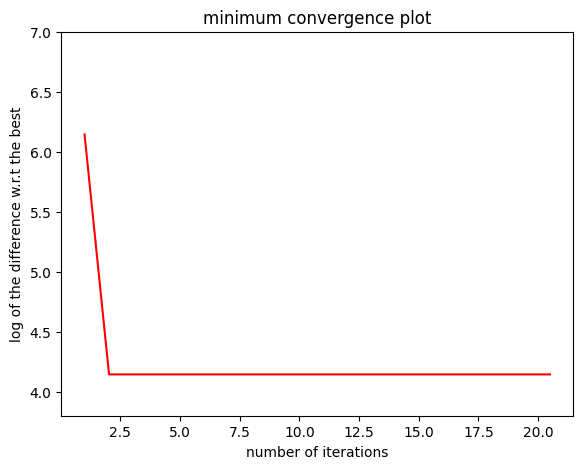

In [6]:
min_ref = -15
mini = np.zeros(n_iter)
for k in range(n_iter):
    mini[k] = np.log(np.abs(np.min(y_data[0 : k + n_doe - 1]) - min_ref))
x_plot = np.linspace(1, n_iter + 0.5, n_iter)
up = max(np.floor(max(mini)) + 1, -100)
lo = max(np.floor(min(mini)) - 0.2, -10)
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes.plot(x_plot, mini, color="r")
axes.set_ylim([lo, up])
plt.title("minimum convergence plot", loc="center")
plt.xlabel("number of iterations")
plt.ylabel("log of the difference w.r.t the best")